In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

from IPython.display import display




In [6]:
import yfinance as yf

stock = input("Enter stock symbol (Ex. TCS, RELIANCE, INFY): ").upper()

stock += ".NS"

print("Downloading data.....")

try:
    df = yf.download(stock, period="1y")

    if df.empty:
        print("Please enter a valid stock symbol. Data not found!")
    else:
        print("Download successful!\n")

        df=df.sort_index()
        
        
        

        filename = f"data/{stock}.csv"
        df.to_csv(filename)

        pd.read_csv(filename)

        display(df)

except Exception as e:
    print("An error occurred while downloading data.")
    print("Error:", e)

Enter stock symbol (Ex. TCS, RELIANCE, INFY):  tcs


[*********************100%***********************]  1 of 1 completed

Download successful!



Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2025-08-04,2951.859863,2956.660572,2872.360310,2889.162791,2519252
2025-08-05,2941.778564,2954.836588,2920.751551,2951.860054,1927996
2025-08-06,2911.437744,2944.562633,2905.388805,2940.914048,1487081
2025-08-07,2925.552002,2929.968748,2890.890790,2895.787607,2543076
2025-08-08,2915.374512,2937.841971,2904.428989,2926.608358,2762140
...,...,...,...,...,...
2026-07-28,2398.000000,2417.399902,2323.000000,2325.000000,8248513
2026-07-29,2446.600098,2475.500000,2415.100098,2440.000000,7169419


In [4]:
df.head()        # First 5 rows
df.tail()        # Last 5 rows
df.info()        # Data types
df.describe()    # Statistics
df.shape         # Rows and columns
df.columns       # Column names
df.dtypes        # Data types

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-07-17 to 2026-07-17
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   250 non-null    float64
 1   (High, TCS.NS)    250 non-null    float64
 2   (Low, TCS.NS)     250 non-null    float64
 3   (Open, TCS.NS)    250 non-null    float64
 4   (Volume, TCS.NS)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


Price   Ticker
Close   TCS.NS    float64
High    TCS.NS    float64
Low     TCS.NS    float64
Open    TCS.NS    float64
Volume  TCS.NS      int64
dtype: object

In [7]:
df["Return"] = df["Close"].pct_change()
print(df["Return"].head())

Date
2025-08-04         NaN
2025-08-05   -0.003415
2025-08-06   -0.010314
2025-08-07    0.004848
2025-08-08   -0.003479
Name: Return, dtype: float64


In [43]:
#cheak data and cleaning


In [8]:
df.isnull().sum()

Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
Return            1
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print(df.index)

DatetimeIndex(['2025-08-04', '2025-08-05', '2025-08-06', '2025-08-07',
               '2025-08-08', '2025-08-11', '2025-08-12', '2025-08-13',
               '2025-08-14', '2025-08-18',
               ...
               '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
               '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30',
               '2026-07-31', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', length=249, freq=None)


In [49]:
df = df.reset_index()

In [52]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   index   250 non-null    int64         
 1   Date    250 non-null    datetime64[ns]
 2   Close   250 non-null    float64       
 3   High    250 non-null    float64       
 4   Low     250 non-null    float64       
 5   Open    250 non-null    float64       
 6   Volume  250 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 13.8 KB
None


In [10]:
df.columns = df.columns.get_level_values(0)
df = df.reset_index()

In [59]:
df.isnull().sum()

Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64

In [56]:
print(df["Close"].describe())

Ticker       TCS.NS
count    250.000000
mean    2775.239898
std      349.332874
min     1982.599976
25%     2440.804932
50%     2925.470337
75%     3050.258911
max     3293.697266


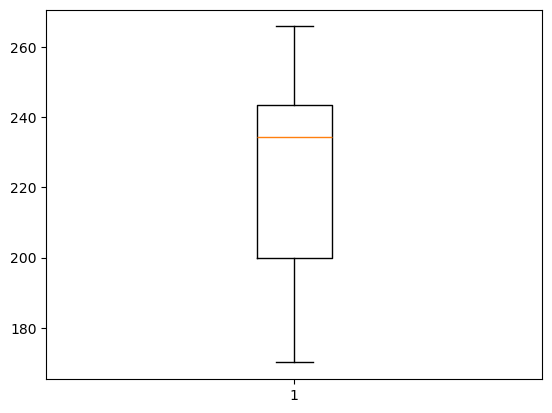

In [5]:
import matplotlib.pyplot as plt

plt.boxplot(df["Close"])
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2026-07-03 to 2025-07-03
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   250 non-null    float64
 1   (High, TCS.NS)    250 non-null    float64
 2   (Low, TCS.NS)     250 non-null    float64
 3   (Open, TCS.NS)    250 non-null    float64
 4   (Volume, TCS.NS)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [6]:
df.columns

MultiIndex([( 'Close', 'TCS.NS'),
            (  'High', 'TCS.NS'),
            (   'Low', 'TCS.NS'),
            (  'Open', 'TCS.NS'),
            ('Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])

In [3]:
import matplotlib.pyplot as plt

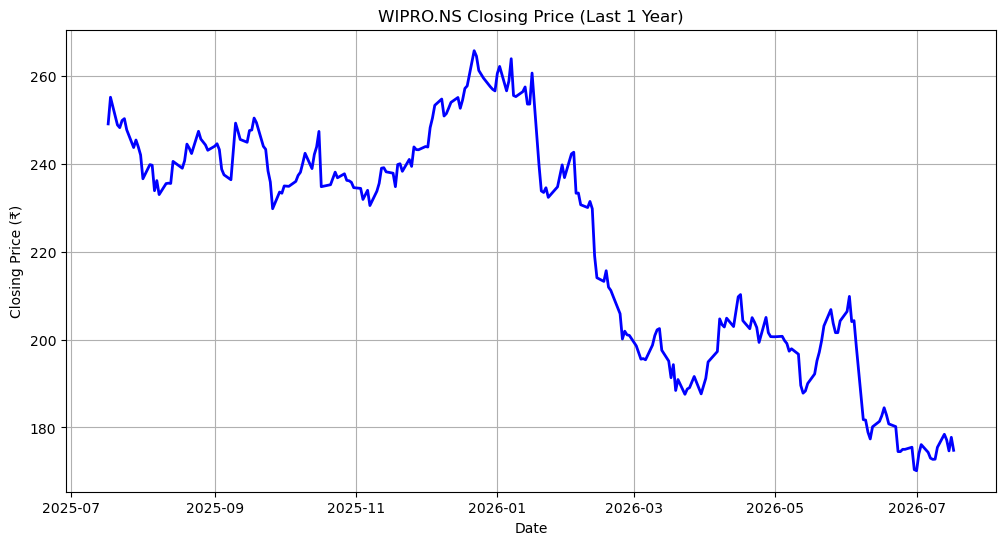

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"], color="blue", linewidth=2)

plt.title(f"{stock} Closing Price (Last 1 Year)")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.grid(True)

plt.show()

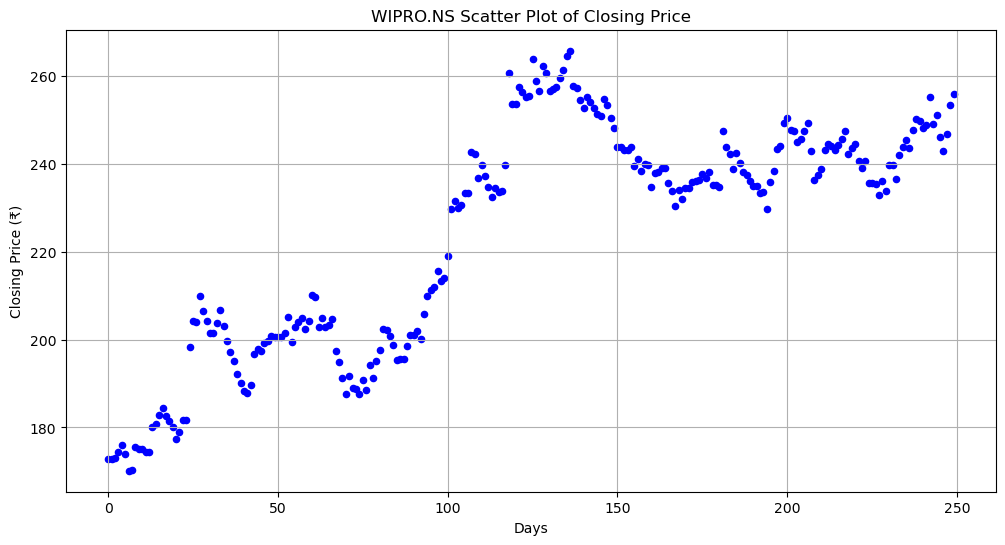

In [37]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df))


y = df["Close"].squeeze()

plt.figure(figsize=(12,6))

plt.scatter(x, y, color="blue", s=20)

plt.title(f"{stock} Scatter Plot of Closing Price")
plt.xlabel("Days")
plt.ylabel("Closing Price (₹)")
plt.grid(True)

plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

x = np.arange(len(df)).reshape(-1, 1)
y = df["Close"].squeeze()

model = LinearRegression()
model.fit(x, y)

pred = model.predict(x)

print("R² Score:", r2_score(y, pred))

R² Score: 0.6927773865263636


R² Score: 0.9040886289821918


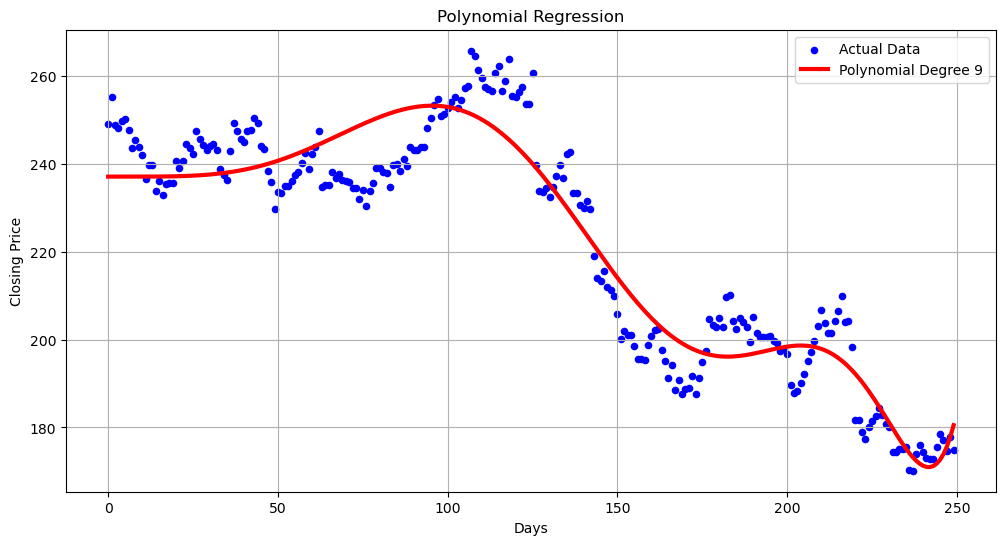

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# X and y
X = np.arange(len(df)).reshape(-1,1)
y = df["Close"].squeeze()

# Degree of polynomial
degree = 9

poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

# R² Score
print("R² Score:", r2_score(y, y_pred))

# Plot
plt.figure(figsize=(12,6))

plt.scatter(X, y, color="blue", s=20, label="Actual Data")
plt.plot(X, y_pred, color="red", linewidth=3, label=f"Polynomial Degree {degree}")

plt.title("Polynomial Regression")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [93]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

model.fit(X, y)

y_pred = model.predict(X)

print("R²:", r2_score(y, y_pred))

R²: 0.7865783859904645


R² Score: 1.0


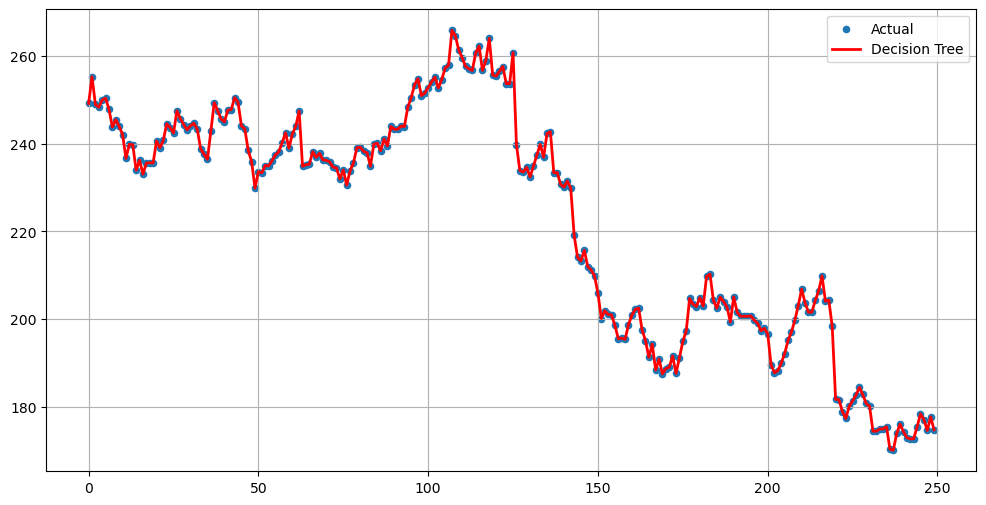

In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

X = np.arange(len(df)).reshape(-1,1)
y = df["Close"].squeeze()

model = DecisionTreeRegressor(random_state=42)

model.fit(X, y)

y_pred = model.predict(X)

print("R² Score:", r2_score(y, y_pred))

plt.figure(figsize=(12,6))
plt.scatter(X, y, s=20, label="Actual")
plt.plot(X, y_pred, color="red", linewidth=2, label="Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
import numpy as np
import pandas as pd

close = df["Close"].squeeze().reset_index(drop=True)

lag = 5

X = []
y = []

for i in range(lag, len(close)):
    X.append(close[i-lag:i].values)
    y.append(close[i])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (245, 5)
y Shape: (245,)


In [60]:
test_days = 30

X_train = X[:-test_days]
X_test = X[-test_days:]

y_train = y[:-test_days]
y_test = y[-test_days:]

In [61]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

print("Actual Prices")
print(y_test)

print("\nPredicted Prices")
print(y_pred)

print("\nR² Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", root_mean_squared_error(y_test, y_pred))

Actual Prices
[244.5269165  240.74458313 239.03862    240.5983429  235.56820679
 235.63644409 235.53895569 233.03364563 236.22135925 233.92074585
 239.72099304 239.85746765 236.64051819 242.05084229 243.90301514
 245.4627533  243.75680542 247.80236816 250.33583069 249.90559387
 248.28036499 248.90179443 255.21157837 249.14079285 251.24403381
 246.08149719 243.07000732 246.94190979 253.39509583 256.02416992]

Predicted Prices
[243.71780904 247.5177002  238.99962107 241.33434296 238.99962107
 232.24727885 238.5121994  233.70627594 233.70627594 235.52272034
 236.07146835 251.50945282 235.78142802 238.97576141 235.78142802
 241.62516785 243.14266459 244.32869466 247.5177002  248.83242289
 248.83242289 243.3766098  243.3766098  254.07053121 243.3766098
 254.07053121 245.27754211 243.71780904 245.27754211 254.07053121]

R² Score : 0.3798682154546832
MAE : 3.8771979861789285
RMSE : 5.019716471859166


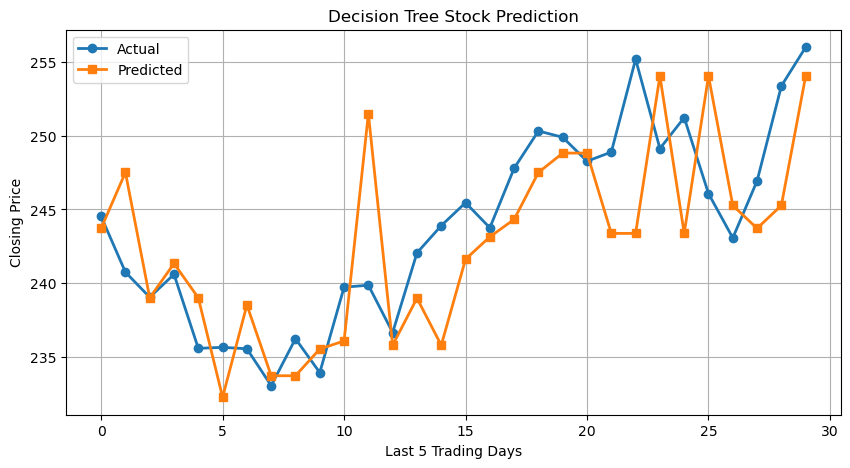

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    range(len(y_test)),
    y_test,
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker='s',
    linewidth=2,
    label="Predicted"
)

plt.title("Decision Tree Stock Prediction")
plt.xlabel("Last 5 Trading Days")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

Actual Prices
[181.75999451 181.66999817 178.92999268 177.36999512 180.13999939
 181.38000488 182.66999817 184.47000122 182.83999634 180.80000305
 180.17999268 174.49000549 174.47999573 175.         175.
 175.47999573 170.38999939 170.13000488 174.         176.08000183
 174.32000732 173.         172.72000122 172.75999451 175.46000671
 178.42999268 177.13999939 174.6499939  177.74000549 174.77999878]

Predicted Prices
[201.29819025 169.00201494 174.24572402 183.55408042 172.03492981
 180.59775127 183.11290934 183.5790159  185.38169499 183.32349089
 180.11649698 180.42527244 173.67507608 172.37808686 176.76706329
 175.26426487 176.15345696 169.78314337 168.41391067 175.31560585
 178.56115594 174.18051621 172.61023507 173.42201984 173.43430266
 176.654077   180.41153155 177.71929624 173.71241172 177.87566213]

R² Score : -1.0511635399096413
MAE : 3.5229766913653786
RMSE : 5.374608740094297


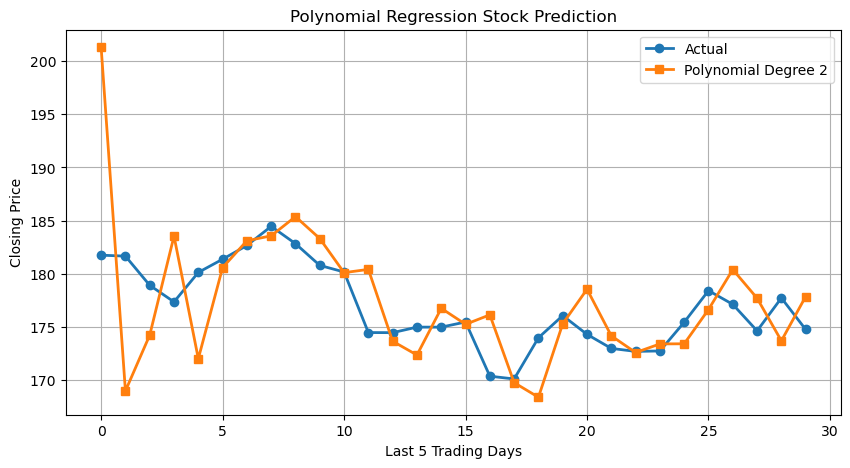

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error



close = df["Close"].squeeze().reset_index(drop=True)

lag = 5

X = []
y = []

for i in range(lag, len(close)):
    X.append(close[i-lag:i].values)
    y.append(close[i])

X = np.array(X)
y = np.array(y)



test_days = 30

X_train = X[:-test_days]
X_test = X[-test_days:]

y_train = y[:-test_days]
y_test = y[-test_days:]



degree = 2

model = make_pipeline(
    PolynomialFeatures(degree),
    LinearRegression()
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)



print("Actual Prices")
print(y_test)

print("\nPredicted Prices")
print(y_pred)

print("\nR² Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", root_mean_squared_error(y_test, y_pred))



plt.figure(figsize=(10,5))

plt.plot(
    range(len(y_test)),
    y_test,
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker='s',
    linewidth=2,
    label=f"Polynomial Degree {degree}"
)

plt.title("Polynomial Regression Stock Prediction")
plt.xlabel("Last 5 Trading Days")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

         Actual    Predicted
0   2626.098633  2626.098633
1   2525.423096  2525.423096
2   2579.980225  2579.980225
3   2598.035156  2598.035156
4   2587.928223  2587.928223
..          ...          ...
95  2169.604248  2169.604248
96  2188.600098  2188.600098
97  2189.199951  2189.199951
98  2201.000000  2201.000000
99  2269.000000  2269.000000

[100 rows x 2 columns]

R² Score : 1.0
MAE : 0.0
RMSE : 0.0


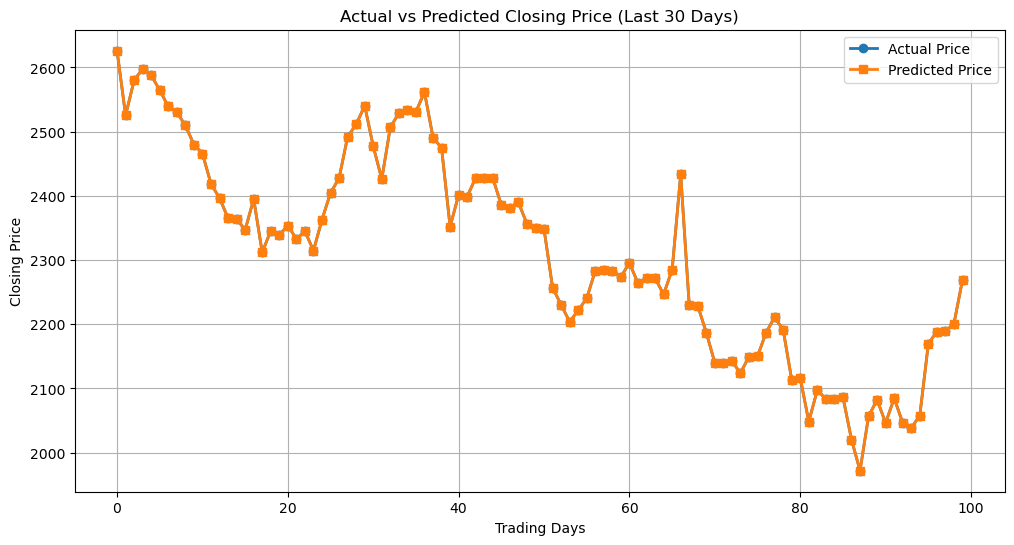

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error


X = df[["Open", "High", "Low","Close", "Volume"]].copy()

y = df["Close"].squeeze()



test_days = 100

X_train = X.iloc[:-test_days]
X_test = X.iloc[-test_days:]

y_train = y.iloc[:-test_days]
y_test = y.iloc[-test_days:]


model = LinearRegression()

model.fit(X_train, y_train)



y_pred = model.predict(X_test)



result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result)



print("\nR² Score :", round(r2_score(y_test, y_pred),4))
print("MAE :", round(mean_absolute_error(y_test, y_pred),4))
print("RMSE :", round(root_mean_squared_error(y_test, y_pred),4))



plt.figure(figsize=(12,6))

plt.plot(
    result["Actual"],
    marker='o',
    linewidth=2,
    label="Actual Price"
)

plt.plot(
    result["Predicted"],
    marker='s',
    linewidth=2,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Closing Price (Last 30 Days)")
plt.xlabel("Trading Days")
plt.ylabel("Closing Price")
plt.grid(True)
plt.legend()

plt.show()

         Actual    Predicted
0   2626.098633  2626.098633
1   2525.423096  2525.423096
2   2579.980225  2579.980225
3   2598.035156  2598.035156
4   2587.928223  2587.928223
..          ...          ...
95  2169.604248  2169.604248
96  2188.600098  2188.600098
97  2189.199951  2189.199951
98  2201.000000  2201.000000
99  2269.000000  2269.000000

[100 rows x 2 columns]

R² Score : 1.0
MAE : 0.0
RMSE : 0.0


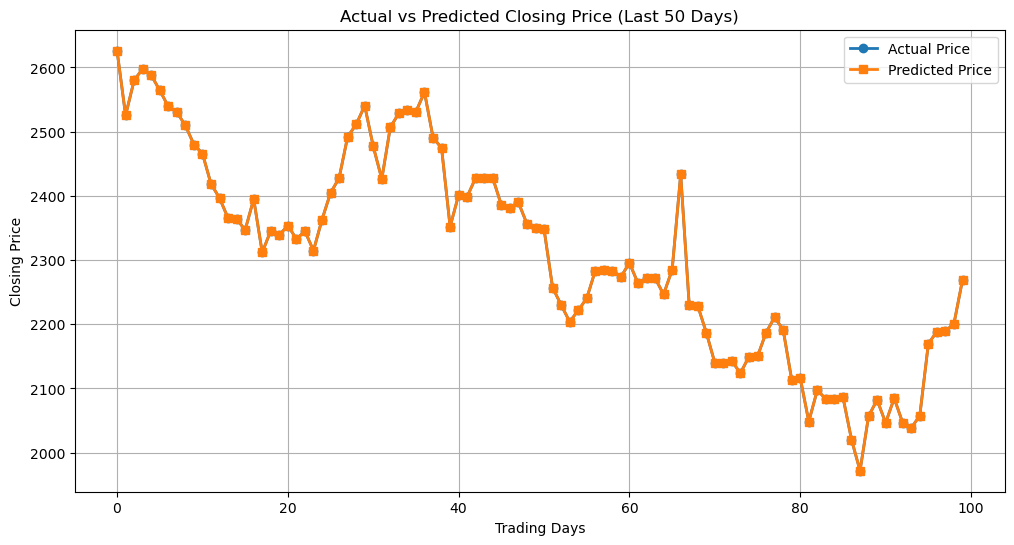

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# -----------------------------
# Features (Independent Variables)
# -----------------------------
X = df[["Open", "High", "Low","Close", "Volume"]]

# -----------------------------
# Target (Dependent Variable)
# -----------------------------
y = df["Close"]      # Use single brackets

# -----------------------------
# Train/Test Split
# -----------------------------
test_days = 100

X_train = X.iloc[:-test_days]
X_test = X.iloc[-test_days:]

y_train = y.iloc[:-test_days]
y_test = y.iloc[-test_days:]

# -----------------------------
# Train Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

# Convert to 1-D arrays
y_test = y_test.to_numpy().flatten()
y_pred = y_pred.flatten()

# -----------------------------
# Result Table
# -----------------------------
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result)

# -----------------------------
# Evaluation Metrics
# -----------------------------
print("\nR² Score :", round(r2_score(y_test, y_pred), 4))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE :", round(root_mean_squared_error(y_test, y_pred), 4))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(result["Actual"],
         marker='o',
         linewidth=2,
         label="Actual Price")

plt.plot(result["Predicted"],
         marker='s',
         linewidth=2,
         label="Predicted Price")

plt.title("Actual vs Predicted Closing Price (Last 50 Days)")
plt.xlabel("Trading Days")
plt.ylabel("Closing Price")
plt.grid(True)
plt.legend()

plt.show()

In [7]:
# 172.759995	174.289993	171.649994	173.000000

# 10y 0  173.057192  174.718856  171.055133  172.876916

         Actual    Predicted
0   2626.098633  2626.530641
1   2525.423096  2525.754279
2   2579.980225  2580.938012
3   2598.035156  2598.829168
4   2587.928223  2588.285735
..          ...          ...
95  2169.604248  2168.547306
96  2188.600098  2191.412236
97  2189.199951  2188.705133
98  2201.000000  2203.256073
99  2269.000000  2268.874864

[100 rows x 2 columns]

Polynomial Degree : 2
R² Score : 0.9999
MAE : 1.3282
RMSE : 1.6187


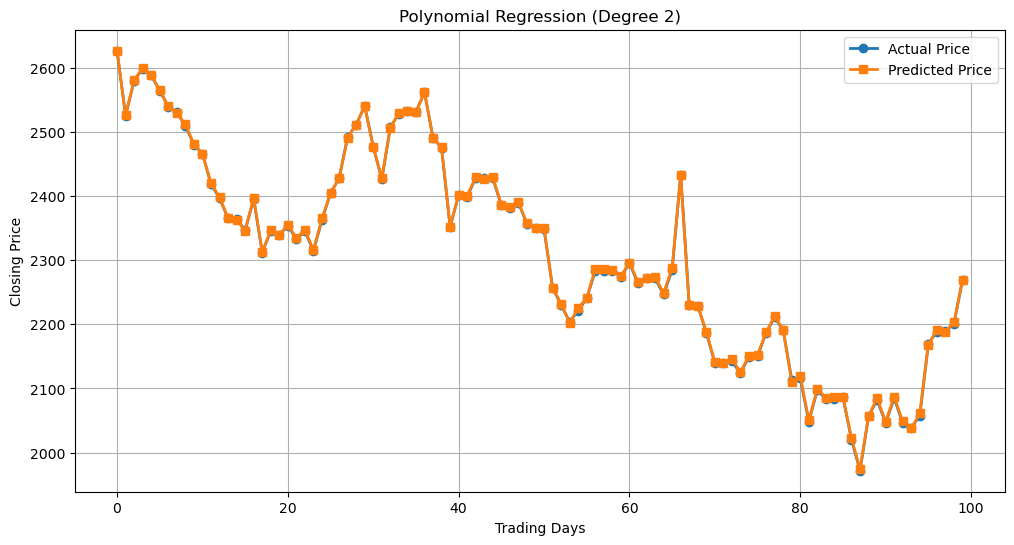

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# -----------------------------
# Features
# -----------------------------
X = df[["Open", "High", "Low","Close", "Volume"]]

# Target
y = df["Close"]

# -----------------------------
# Train/Test Split
# -----------------------------
test_days = 100

X_train = X.iloc[:-test_days]
X_test = X.iloc[-test_days:]

y_train = y.iloc[:-test_days]
y_test = y.iloc[-test_days:]

# -----------------------------
# Polynomial Regression Model
# -----------------------------
degree = 2

model = make_pipeline(
    PolynomialFeatures(degree=degree),
    LinearRegression()
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Convert to 1D
y_test = y_test.to_numpy().flatten()
y_pred = y_pred.flatten()

# -----------------------------
# Result Table
# -----------------------------
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result)

# -----------------------------
# Evaluation
# -----------------------------
print("\nPolynomial Degree :", degree)
print("R² Score :", round(r2_score(y_test, y_pred), 4))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE :", round(root_mean_squared_error(y_test, y_pred), 4))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(result["Actual"],
         marker='o',
         linewidth=2,
         label="Actual Price")

plt.plot(result["Predicted"],
         marker='s',
         linewidth=2,
         label="Predicted Price")

plt.title(f"Polynomial Regression (Degree {degree})")
plt.xlabel("Trading Days")
plt.ylabel("Closing Price")
plt.grid(True)
plt.legend()

plt.show()